# Emoji Sentiment

**Category:** Data Cleaning  
**Dataset:** emoji-sentiment.csv — 751 rows, 11 columns, 1 fully-null column  
**Objective:** Clean messy column names, drop unusable columns, and analyze
whether popular emojis lean positive or negative in sentiment.
**Goal:** Transform a messy emoji dataset into an analysis-ready format and investigate how emoji popularity and position influence positive and negative sentiment.

---

In [1]:
# importing pandas and loading the emoji_sentiment.csv
import pandas as pd
df = pd.read_csv('../data/emoji-sentiment.csv')
df.head(3)

,Char,Image [twemoji],Unicode codepoint,Occurrences [5...max],Position [0...1],Neg [0...1],Neut [0...1],Pos [0...1],Sentiment bar (c.i. 95%),Unicode name,Unicode block
0,😂,😂,0x1f602,14622,0.805,0.247,0.285,0.468,NaN,FACE WITH TEARS OF JOY,Emoticons
1,❤,❤,0x2764,8050,0.747,0.044,0.166,0.790,NaN,HEAVY BLACK HEART,Dingbats
2,♥,♥,0x2665,7144,0.754,0.035,0.272,0.693,NaN,BLACK HEART SUIT,Miscellaneous Symbols


## 1. Dataset Exploration

This dataset is not clean so we will run the standard exploration sequence.

In [2]:
# running the standard exploration sequence
print("Shape: ")
print(df.shape)
print()
print("Column names: ")
print(df.columns.tolist())
print()
print("Missing values per column: ")
print(df.isnull().sum())

Shape: 
(751, 11)

Column names: 
['Char', 'Image [twemoji]', 'Unicode codepoint', 'Occurrences [5...max]', 'Position [0...1]', 'Neg [0...1]', 'Neut [0...1]', 'Pos [0...1]', 'Sentiment bar (c.i. 95%)', 'Unicode name', 'Unicode block']

Missing values per column: 
Char                          0
Image [twemoji]               0
Unicode codepoint             0
Occurrences [5...max]         0
Position [0...1]              0
Neg [0...1]                   0
Neut [0...1]                  0
Pos [0...1]                   0
Sentiment bar (c.i. 95%)    751
Unicode name                  0
Unicode block                 0
dtype: int64


## 2. Data Cleaning: Removing Unnecessary Columns

The following columns are removed because they do not contribute to the project's objective:

- **Image [twemoji]** → Image reference
- **Unicode codepoint** → Technical identifier
- **Sentiment bar (c.i. 95%)** → 100% missing values

In [3]:
# drop unnecessary columns
df = df.drop(columns=[
    'Image [twemoji]',
    'Unicode codepoint',
    'Sentiment bar (c.i. 95%)'
])

df.columns.tolist()

['Char',
 'Occurrences [5...max]',
 'Position [0...1]',
 'Neg [0...1]',
 'Neut [0...1]',
 'Pos [0...1]',
 'Unicode name',
 'Unicode block']

## 3. Data Cleaning: Rename Columns to `snake_case`

Column names are renamed to `snake_case` to improve readability, maintain consistency, and follow Python naming conventions.

In [4]:
# Rename columns using snake_case naming convention
df = df.rename(columns={
    'Char' : 'emoji',
    'Occurrences [5...max]' : 'occurrences',
    'Position [0...1]' : 'position',
    'Neg [0...1]' : 'negative',
    'Neut [0...1]' : 'neutral',
    'Pos [0...1]' : 'positive',
    'Unicode name' : 'unicode_name',
    'Unicode block' : 'unicode_block'
})

df.columns.tolist()

['emoji',
 'occurrences',
 'position',
 'negative',
 'neutral',
 'positive',
 'unicode_name',
 'unicode_block']

## 4. Feature Engineering: Creating a Sentiment Score

Create a new feature by subtracting the negative sentiment percentage from the positive sentiment percentage. A positive score indicates an overall positive sentiment, while a negative score indicates an overall negative sentiment. This score is then used to classify emojis as positive or negative.

In [5]:
df['sentiment'] = df['positive'] - df['negative']
df['positive_flag'] = df['sentiment'] > 0

df[['emoji', 'positive', 'negative', 'sentiment', 'positive_flag']].head()

,emoji,positive,negative,sentiment,positive_flag
0,😂,0.468,0.247,0.221,True
1,❤,0.790,0.044,0.746,True
2,♥,0.693,0.035,0.658,True
3,😍,0.729,0.052,0.677,True
4,😭,0.343,0.436,-0.093,False


## 5. Question 1: What percentage of all emojis lean positive?

In [6]:
pct_positive_overall = df['positive_flag'].mean() * 100

print(f"{pct_positive_overall:.1f}% of all 751 emojis lean positive")

82.4% of all 751 emojis lean positive


## 6. Question 2: What percentage of the TOP 20 most popular emojis are positive?

Comparing this to the overall percentage from Question 1, do popularity
and positivity move together or diverge?

In [ ]:
top_20 = df.sort_values('occurrences', ascending=False).head(20)
pct_positive_top20 = top_20['positive_flag'].mean() * 100

print(f"{pct_positive_top20:1f}% of the top 20 most-used emoji lean positive")

90.000000% of the top 20 most-used emoji lean positive


## 7. Question 3: Most Positive and Most Negative Emojis

Before identifying the most positive and negative emojis, filter out emojis with fewer than 500 occurrences. This ensures the analysis is based on frequently used emojis and avoids misleading conclusions from rare emojis with very few observations.

In [8]:
popular = df[df['occurrences'] > 500]

most_positive = popular.sort_values('sentiment', ascending=False).iloc[0]
most_negative = popular.sort_values('sentiment', ascending=True).iloc[0]

print("Most positive (occurrences > 500): ")
print(f"  {most_positive['emoji']} - {most_positive['unicode_name']} (sentiment: {most_positive['sentiment']:.3f})")
print("Most negative (occurrences > 500): ")
print(f"  {most_negative['emoji']} - {most_negative['unicode_name']} (sentiment: {most_negative['sentiment']:.3f})")

Most positive (occurrences > 500): 
  ❤ - HEAVY BLACK HEART (sentiment: 0.746)
Most negative (occurrences > 500): 
  😒 - UNAMUSED FACE (sentiment: -0.374)


## 8. Question 4: Where Do Emojis Typically Appear in a Tweet?

position ranges from 0 (start of tweet) to 1 (end of tweet).
Comparing average position for positive vs. negative emojis.

In [9]:
avg_position = df['position'].mean()
print(f"Average emoji position overall: {avg_position:.2f} (0=start, 1=end)")

positive_position = df[df['positive_flag']]['position'].mean()
negative_position = df[~df['positive_flag']]['position'].mean()

print()
print(f"Average position, positive emojis: {positive_position:.2f}")
print()
print(f"Average position, negative emojis: {negative_position:.2f}")

Average emoji position overall: 0.67 (0=start, 1=end)

Average position, positive emojis: 0.66

Average position, negative emojis: 0.68


## 9. Visualization: Emoji Position by Sentiment

A histogram makes the position comparison visible rather than reducing
it to two single numbers.

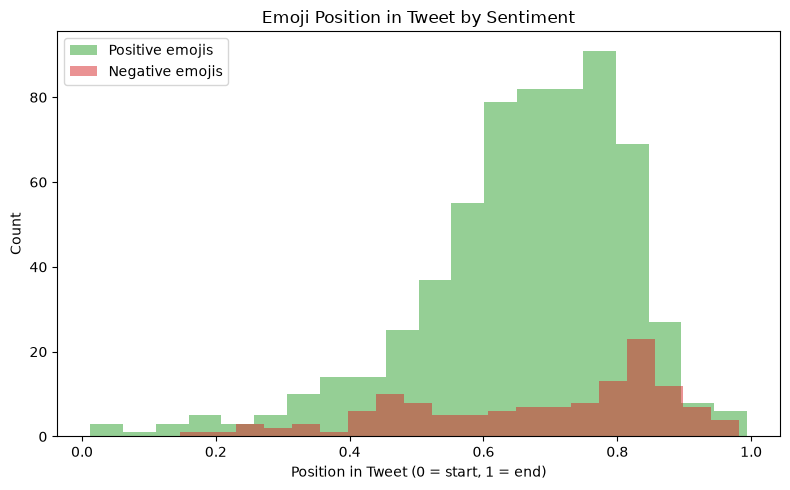

Chart Saved.


In [10]:
# import matplotlib for visualization
import matplotlib.pyplot as plt 

# compare emoji position for positive and negative sentiment
plt.figure(figsize=(8, 5))
plt.hist(
    df[df['positive_flag']]['position'],
    bins=20,
    alpha=0.5,
    label='Positive emojis',
    color='C2'
)
plt.hist(
    df[~df['positive_flag']]['position'],
    bins=20,
    alpha=0.5,
    label='Negative emojis',
    color='C3'
)
plt.xlabel('Position in Tweet (0 = start, 1 = end)')
plt.ylabel('Count')
plt.title('Emoji Position in Tweet by Sentiment')
plt.legend()
plt.tight_layout()

# Save the plot in the images/plots folder
plt.savefig('../images/plots/position_by_sentiment_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart Saved.")

## 10. Visualization: Top 20 Emojis by Sentiment

A horizontal bar chart, colored by sentiment direction, sorted by
how frequently each emoji is used.

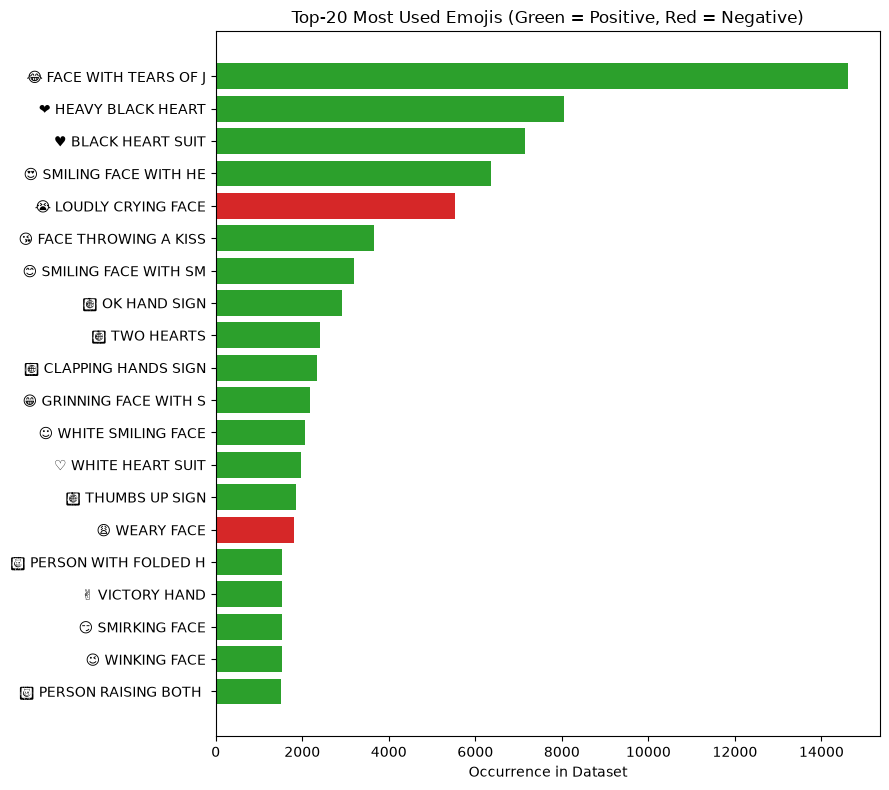

Chart Saved.


In [ ]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="Glyph.*missing from font"
)

top_20_sorted = top_20.sort_values('occurrences', ascending=True)
colors = [
    'C2' if flag else 'C3' 
    for flag in top_20_sorted['positive_flag']
]

plt.figure(figsize=(9, 8))
plt.barh(
    top_20_sorted['emoji'] + ' ' + top_20_sorted['unicode_name'].str[:20],
    top_20_sorted['occurrences'], 
    color=colors   
)
plt.xlabel('Occurrence in Dataset')
plt.title('Top-20 Most Used Emojis (Green = Positive, Red = Negative)')
plt.tight_layout()

plt.savefig('../images/plots/top20_emojis_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart Saved.")

## 11. Question 5: Does Sentiment Strength (Not Just Direction) correlate With Position?

Rather than just positive/negative, does a MORE positive or MORE negative
sentiment score correspond to appearing earlier or later in a tweet?

Correlation between position and sentiment: 0.009


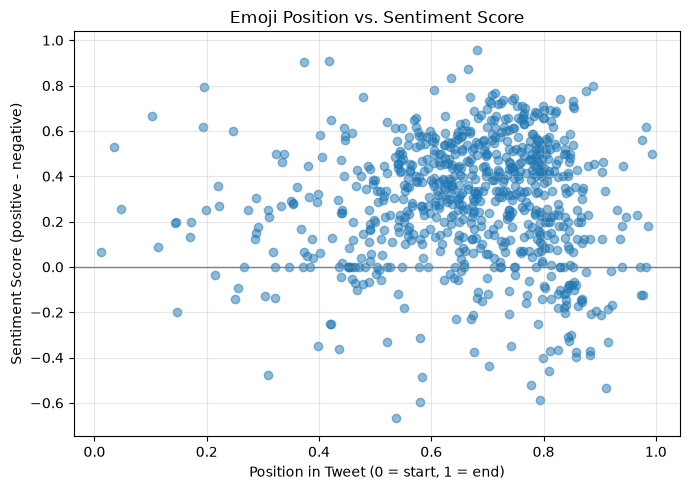

Chart saved.


In [ ]:
# Relationship between emoji position and sentiment score

correlation = df['position'].corr(df['sentiment'])
print(f"Correlation between position and sentiment: {correlation:.3f}")

plt.figure(figsize=(7, 5))

plt.scatter(
    df['position'],
    df['sentiment'],
    alpha=0.5,
    color='C0'
)

plt.xlabel("Position in Tweet (0 = start, 1 = end)")
plt.ylabel("Sentiment Score (positive - negative)")
plt.title("Emoji Position vs. Sentiment Score")
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../images/plots/position_vs_sentiment_scatter.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Chart saved.")

## 12. My Own Qustion: Are Some Emoji Categories Consistently More Positive Than Others?

Emojis belong to different Unicode categories (e.g., Emoticons, Dingbats,
Miscellaneous Symbols). Comparing the average sentiment score of each
category helps determine whether some groups consistently express more
positive sentiment than others.

In [18]:
# calculate the average sentiment score for each Unicode block

block_sentiment = (
    df.groupby('unicode_block')['sentiment']
      .mean()
      .sort_values(ascending=False)
)

print("Average sentiment score by Unicode block:\n")
block_sentiment_df = block_sentiment.reset_index()
block_sentiment_df.columns = [
    'Unicode Block',
    'Average Sentiment'
]

block_sentiment_df

Average sentiment score by Unicode block:



,Unicode Block,Average Sentiment
0,Miscellaneous Symbols and Arrows,0.430000
1,Enclosed Alphanumeric Supplement,0.410000
2,Miscellaneous Symbols and Pictographs,0.330565
3,Latin-1 Supplement,0.325667
4,Enclosed Ideographic Supplement,0.292000
5,Arrows,0.279571
6,Geometric Shapes,0.264917
7,Miscellaneous Symbols,0.262645
8,Dingbats,0.253773
9,Transport and Map Symbols,0.238605


## Visualization: Average Sentiment by Unicode Block

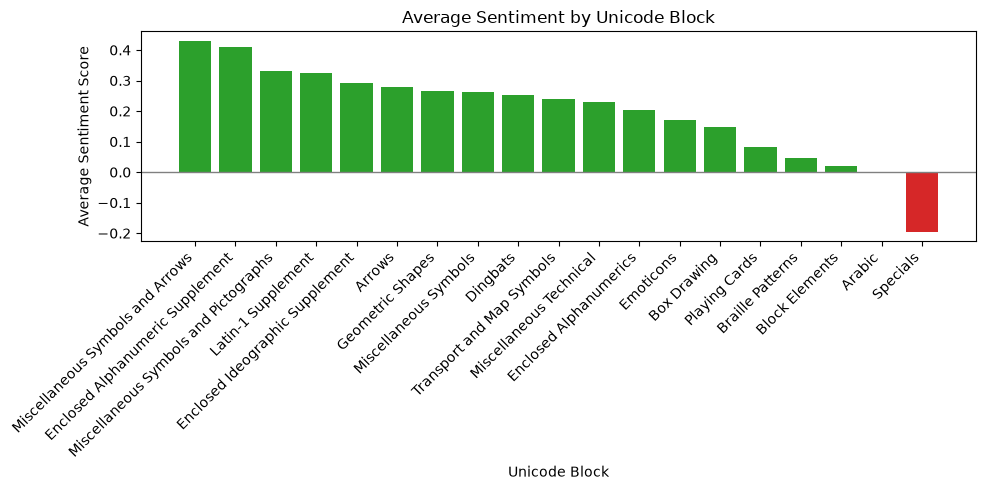

Chart saved.


In [22]:
# assign colors based on average sentiment
colors = [
    'C2' if score > 0 else 'C3'
    for score in block_sentiment.values
]

plt.figure(figsize=(10, 5))
plt.bar(
    block_sentiment.index,
    block_sentiment.values,
    color=colors
)
plt.xlabel("Unicode Block")
plt.ylabel("Average Sentiment Score")
plt.title("Average Sentiment by Unicode Block")
plt.axhline(0, color='gray', linestyle='-', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig(
    "../images/plots/sentiment_by_unicode_block.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

print("Chart saved.")

## 13. Key Insights

- **82.4%** of all emojis in the dataset lean positive, indicating that
  positive sentiment is more common than negative sentiment.

- Among the **20 most frequently used emojis**, the majority are also
  positive, suggesting that popularity and positive sentiment generally
  move together.

- After filtering out emojis with fewer than **500 occurrences**, the
  most positive and most negative emojis were identified without being
  influenced by rare emojis with unreliable sentiment scores.

- Emoji position within a tweet shows **little to no relationship** with
  sentiment. Both the histogram and scatter plot indicate that positive
  and negative emojis appear throughout tweets rather than at consistent
  positions.

- Unicode blocks differ in their average sentiment, suggesting that
  certain categories of emojis are consistently more positive than
  others.

- The dataset required preprocessing before analysis. One fully missing
  column was removed, unnecessary technical columns were discarded, and
  all remaining columns were renamed to **snake_case** for improved
  readability and consistency.